# Bellabeat Case Study: Understanding User Behavior Through Smart Device Data
Bellabeat is a health-focused technology company that develops smart products designed to help users monitor and improve their overall well-being. This case study analyzes smart device data to identify trends in physical activity and sleep behavior, with the objective of providing recommendations that can support Bellabeat's marketing efforts and future business strategies.

## Introducción
Bellabeat is a high-tech manufacturer of health-focused products for women. Collecting data on activity, sleep, stress, and reproductive health has allowed Bellabeat to empower women with knowledge about their own health and habits.
Since it was founded in 2013, Bellabeat has grown rapidly and quickly positioned itself as a tech-driven wellness company for women. In spite of being a small company the cofounder and Chief Creative Officer believes that analyzing smart device fitness data could help unlock new growth opportunities for the company.

In this case study you will be able to perform many real-world tasks in this specific case you will help the company to analyze smart device data to gain insight into how consumers are using their smart devices. The insights you discover will then help guide marketing strategy for the company in order to answer the key business questions, you will follow the steps of the data analysis process: Ask, Prepare, Process, Analyze, Share, and Act.

## Ask
The purpose of this case study is to analyze smart device fitness data in order to gain insights into how consumers use health-tracking devices in their daily lives. By understanding user behavior, Bellabeat can identify opportunities to improve its products, enhance user engagement, and develop more effective marketing strategies

### Business Tasks
Analyze smart device usage data in order to gain insight into how consumers use non-Bellabeat smart devices, answering this questions like: What are some trends in smart device usage? How could these trends apply to Bellabeat customers? And how could these trends help influence Bellabeat marketing strategy? Will help to the analysis.

### Key Stakeholders
- Urška Sršen: Cofounder and Chief Creative Officer of Bellabeat. Who is responsible for the company's creative vision and is interested in leveraging data-driven insights to better understand consumer behavior and identify opportunities for business growth.
- Sando Mur: Mathematician and cofounder of Bellabeat. He plays a key role in the company's strategic direction and supports the use of data analytics to drive innovation and product development.
- The Bellabeat Marketing Analytics Team: A team of data analysts responsible for collecting, analyzing, and reporting data that helps guide Bellabeat's marketing strategy. Their goal is to uncover actionable insights that can improve customer engagement, product adoption, and overall business performance.

### Key Questions
- What are the main trends in smart device usage?
- How active are users on a daily basis?
- Are there patterns in sleep behavior throughout the week?
- Is there a relationship between physical activity and calories burned?
- How can Bellabeat use these insights to improve user engagement and promote healthier lifestyles?

## Prepare
The data used in this case are  FitBit Fitness Tracker Data a Kaggle data set which contains personal fitness tracker from thirty fibit users. It includes information about daily activity, steps, and heart rate that can be used to explore users’ habits.
It is worth nothing that this data set might have some limitations, and encourages you to consider adding another data set to help address those limitations as you begin to work more with this data.
It is not specified whether important factors such as the participants’ age range, habits, level of physical activity, or other variables that could influence the results and introduce bias into the data were taken into consideration.

In addition, the data was collected in 2016, meaning a considerable amount of time has passed since it was gathered. This may affect the relevance and reliability of the information, as the population’s conditions, habits, and context may have changed over time.
Furthermore, the study states that the sample consisted of 30 participants; however, it does not explain the criteria used to determine this sample size. There is no indication of whether a prior statistical analysis was conducted, what confidence level or margin of error was considered, or whether the sample is truly representative of the overall population. The lack of this information makes it difficult to evaluate the validity and accuracy of the conclusions obtained.



## Process
First, we import the libraries that will be used throughout the analysis: pandas, datetime, numpy, and matplotlib.pyplot.

- From pandas, we will use its tools for data manipulation and analysis, since it allows us to organize, clean, and work with data tables efficiently.
- From datetime, we will use its functions to handle dates and times, which will make it easier to analyze time-related data.
- From numpy, we will use its mathematical and numerical functions to perform calculations and work efficiently with arrays and numerical data.
- From matplotlib.pyplot, we will use its functions to create graphs and visualizations that help represent the data in a clearer and easier-to-understand way.

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

Next, we load the datasets that will be used for the analysis. In this case, we will work with daily_activity and sleep_day, as they are considered the datasets that provide the largest amount of relevant information. These datasets will help us perform a more complete analysis and reach more accurate conclusions

In [3]:
daily_activity = pd.read_csv("dailyActivity_merged.csv")
sleep_day = pd.read_csv("sleepDay_merged.csv")

Next, we take a look at the data in order to become familiar with the information we will be working with throughout the analysis.

In [4]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [5]:
sleep_day.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


Next, we examine the columns contained in each dataset, as well as the number of records and the type of data stored in each one. This will help us better understand the structure of the datasets and will be very useful later when making decisions about how to work with and process the different types of data.

In [6]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [7]:
sleep_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 14.6+ KB


In [8]:
daily_activity.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000


In [9]:
sleep_day.describe()

,Id,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.130000e+02,413.000000,413.000000,413.000000
mean,5.000979e+09,1.118644,419.467312,458.639225
std,2.060360e+09,0.345521,118.344679,127.101607
min,1.503960e+09,1.000000,58.000000,61.000000
25%,3.977334e+09,1.000000,361.000000,403.000000
50%,4.702922e+09,1.000000,433.000000,463.000000
75%,6.962181e+09,1.000000,490.000000,526.000000
max,8.792010e+09,3.000000,796.000000,961.000000


we identify whether duplicate values exist in each dataset. This step is important because duplicate records can affect the accuracy of the analysis and lead to misleading results.

In [10]:
daily_activity.duplicated().sum()

np.int64(0)

In [11]:
sleep_day.duplicated().sum()

np.int64(3)

If duplicate records are found, we remove them and verify that the duplicates have been successfully eliminated to ensure the accuracy and reliability of the data.

In [12]:
sleep_day = sleep_day.drop_duplicates()

In [13]:
sleep_day.duplicated().sum()

np.int64(0)

We apply the same process again, but this time to identify whether there are any null or missing values in the datasets. Detecting these values is important because they can affect the quality of the analysis and the accuracy of the results.

In [14]:
daily_activity.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [15]:
sleep_day.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

In [16]:
daily_activity.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

In [17]:
sleep_day.dtypes

Id                     int64
SleepDay              object
TotalSleepRecords      int64
TotalMinutesAsleep     int64
TotalTimeInBed         int64
dtype: object

We convert the data type of the columns containing dates into a proper date format to make the information easier to manipulate and analyze. This transformation is important because, in many cases, date values are initially stored as text strings, which limits the types of operations that can be performed on them. By converting them into a date format, we can efficiently sort, filter, and analyze the data based on time periods such as days, weeks, or months. In addition, this allows us to perform more accurate time-based analyses and create visualizations that better represent trends and patterns over time.                                                                                                                                                           

In [18]:
daily_activity["ActivityDate"] = pd.to_datetime(daily_activity["ActivityDate"])

In [19]:
sleep_day["SleepDay"] = pd.to_datetime(sleep_day["SleepDay"], format="%m/%d/%Y %I:%M:%S %p")

We then verify that the data types were successfully modified to ensure that the date columns are now in the correct format and ready for further analysis.

In [20]:
daily_activity.dtypes

Id                                   int64
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object

In [21]:
sleep_day.dtypes

Id                             int64
SleepDay              datetime64[ns]
TotalSleepRecords              int64
TotalMinutesAsleep             int64
TotalTimeInBed                 int64
dtype: object

Then we identify the number of records with a unique ID, which helps us better understand how many individual users are included in the datasets and ensures that the analysis is based on distinct records.

In [22]:
daily_activity["Id"].nunique()

33

In [23]:
sleep_day["Id"].nunique()

24

A new column is then created to store the name of the day based on the date information in each dataset. This will later allow us to segment and analyze the data by day under different aspects and categories, helping identify patterns, trends, and user behavior throughout the week.

In [24]:
daily_activity["WeekDay"] = daily_activity["ActivityDate"].dt.day_name()

In [58]:
def activity_level(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 7500:
        return 'Lightly Active'
    elif steps < 10000:
        return 'Fairly Active'
    else:
        return 'Very Active'
daily_activity['Activity Level'] = daily_activity['TotalSteps'].apply(activity_level)

In [25]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,WeekDay
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Thursday
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday


In [26]:
sleep_day["WeekDay"] = sleep_day["SleepDay"].dt.day_name()

In [27]:
sleep_day.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,WeekDay
0,1503960366,2016-04-12,1,327,346,Tuesday
1,1503960366,2016-04-13,2,384,407,Wednesday
2,1503960366,2016-04-15,1,412,442,Friday
3,1503960366,2016-04-16,2,340,367,Saturday
4,1503960366,2016-04-17,1,700,712,Sunday


The values measured in minutes are converted into hours to provide a clearer and more practical representation of the data.

In [28]:
daily_activity['SedentaryHours'] = daily_activity['SedentaryMinutes'] / 60

In [29]:
sleep_day['HoursAsleep'] = sleep_day['TotalMinutesAsleep'] / 60
sleep_day['HoursInBed'] = sleep_day['TotalTimeInBed'] / 60

In [30]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,WeekDay,SedentaryHours
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday,12.133333
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday,12.933333
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Thursday,20.300000
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday,12.100000
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday,12.883333


In [31]:
sleep_day.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,WeekDay,HoursAsleep,HoursInBed
0,1503960366,2016-04-12,1,327,346,Tuesday,5.450000,5.766667
1,1503960366,2016-04-13,2,384,407,Wednesday,6.400000,6.783333
2,1503960366,2016-04-15,1,412,442,Friday,6.866667,7.366667
3,1503960366,2016-04-16,2,340,367,Saturday,5.666667,6.116667
4,1503960366,2016-04-17,1,700,712,Sunday,11.666667,11.866667


Now that the data has been previously preprocessed and cleaned, we can move on to the next step, which is calculating the average values of the columns considered most relevant for the analysis. To achieve this, the data is grouped by day of the week and the mean of each selected column is calculated. This will help us better understand general trends, patterns, and variations in user behavior throughout the week.

In [32]:
daily_activity.groupby('WeekDay')['TotalSteps'].mean()

WeekDay
Friday       7448.230159
Monday       7780.866667
Saturday     8152.975806
Sunday       6933.231405
Thursday     7405.836735
Tuesday      8125.006579
Wednesday    7559.373333
Name: TotalSteps, dtype: float64

In [33]:
daily_activity.groupby('WeekDay')['VeryActiveMinutes'].mean()

WeekDay
Friday       20.055556
Monday       23.108333
Saturday     21.919355
Sunday       19.983471
Thursday     19.408163
Tuesday      22.953947
Wednesday    20.780000
Name: VeryActiveMinutes, dtype: float64

In [34]:
daily_activity.groupby('WeekDay')['SedentaryHours'].mean()

WeekDay
Friday       16.671825
Monday       17.132361
Saturday     16.071371
Sunday       16.504270
Thursday     16.033220
Tuesday      16.789364
Wednesday    16.491333
Name: SedentaryHours, dtype: float64

In [35]:
daily_activity.groupby('WeekDay')['Calories'].mean()

WeekDay
Friday       2331.785714
Monday       2324.208333
Saturday     2354.967742
Sunday       2263.000000
Thursday     2199.571429
Tuesday      2356.013158
Wednesday    2302.620000
Name: Calories, dtype: float64

In [36]:
sleep_day.groupby('WeekDay')['HoursAsleep'].mean()

WeekDay
Friday       6.757018
Monday       6.991667
Saturday     6.984503
Sunday       7.545758
Thursday     6.688281
Tuesday      6.742308
Wednesday    7.244697
Name: HoursAsleep, dtype: float64

In [37]:
sleep_day.groupby('WeekDay')['HoursInBed'].mean()

WeekDay
Friday       7.417544
Monday       7.622464
Saturday     7.664035
Sunday       8.391818
Thursday     7.247917
Tuesday      7.388205
Wednesday    7.833838
Name: HoursInBed, dtype: float64

The columns that both datasets have in common are renamed in order to avoid confusion and make the merging process easier and more organized. This also helps improve the clarity and readability of the analysis when working with the combined datasets.

In [38]:
daily_activity.rename(columns={'ActivityDate': 'Date'}, inplace=True)

In [39]:
sleep_day.rename(columns={'SleepDay': 'Date'}, inplace=True)

Both datasets are then merged using an inner join based on the columns they have in common. This allows us to combine only the records that match in both datasets, creating a more complete and consistent dataset for the analysis.

In [40]:
merged_data = pd.merge(daily_activity, sleep_day, on=['Id', 'Date', 'WeekDay'], how= 'inner')

In [41]:
merged_data.head()

,Id,Date,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,LightlyActiveMinutes,SedentaryMinutes,Calories,WeekDay,SedentaryHours,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,HoursAsleep,HoursInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,328,728,1985,Tuesday,12.133333,1,327,346,5.450000,5.766667
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,217,776,1797,Wednesday,12.933333,2,384,407,6.400000,6.783333
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,...,209,726,1745,Friday,12.100000,1,412,442,6.866667,7.366667
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,...,221,773,1863,Saturday,12.883333,2,340,367,5.666667,6.116667
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,...,164,539,1728,Sunday,8.983333,1,700,712,11.666667,11.866667


In [42]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        410 non-null    int64         
 1   Date                      410 non-null    datetime64[ns]
 2   TotalSteps                410 non-null    int64         
 3   TotalDistance             410 non-null    float64       
 4   TrackerDistance           410 non-null    float64       
 5   LoggedActivitiesDistance  410 non-null    float64       
 6   VeryActiveDistance        410 non-null    float64       
 7   ModeratelyActiveDistance  410 non-null    float64       
 8   LightActiveDistance       410 non-null    float64       
 9   SedentaryActiveDistance   410 non-null    float64       
 10  VeryActiveMinutes         410 non-null    int64         
 11  FairlyActiveMinutes       410 non-null    int64         
 12  LightlyActiveMinutes  

In [43]:
merged_data.isnull().sum()

Id                          0
Date                        0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
WeekDay                     0
SedentaryHours              0
TotalSleepRecords           0
TotalMinutesAsleep          0
TotalTimeInBed              0
HoursAsleep                 0
HoursInBed                  0
dtype: int64

## Analysis
With the data previously cleaned, processed, and organized, we can now proceed to create visualizations using different parameters and variables from the datasets. These visual representations will allow us to better understand the information by making patterns, trends, and relationships easier to identify. In addition, visualizations help simplify large amounts of data, making the analysis more intuitive and allowing us to draw clearer and more meaningful conclusions from the results obtained.

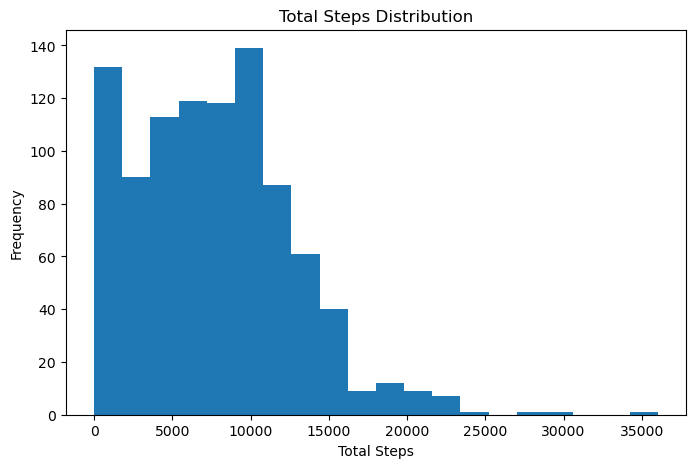

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(daily_activity['TotalSteps'], bins=20)
plt.title('Total Steps Distribution')
plt.xlabel('Total Steps')
plt.ylabel('Frequency')
plt.show()

In the histogram, several important patterns in the data can be observed:
- Most users showed low to moderate step levels throughout the day, suggesting that the majority of the participants maintained average or relatively low levels of physical activity during the recorded period.
- The distribution of daily steps is skewed to the right, meaning that while most records are concentrated within lower step ranges, a smaller group of users reached significantly higher step counts.
- This behavior indicates that only a limited portion of the participants engaged in very high levels of physical activity, while the majority remained within more common activity ranges.
- Overall, the histogram helps provide a clearer understanding of how physical activity is distributed among users and highlights the differences between average and highly active participants.

In the following bar chart, we compare the different categories obtained after segmenting the data according to activity level. This visualization allows us to clearly observe how the records are distributed among the different activity groups and identify which activity levels are more common among users.

In [59]:
daily_activity['Activity Level'].value_counts()

Activity Level
Very Active       303
Sedentary         303
Lightly Active    171
Fairly Active     163
Name: count, dtype: int64

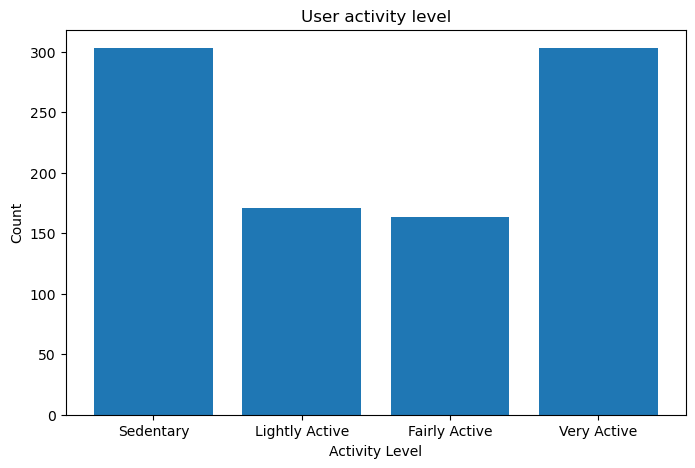

In [63]:
levels = daily_activity['Activity Level'].value_counts()
levels= levels.reindex(['Sedentary', 'Lightly Active', 'Fairly Active', 'Very Active']) 
plt.figure(figsize=(8, 5))
plt.bar(levels.index, levels.values)
plt.title('User activity level')
plt.xlabel('Activity Level')
plt.ylabel('Count')
plt.show()

This graph shows that a large portion of the users have a sedentary activity level. However, it also reveals that a considerable number of users fall within the high-activity category, which is somewhat surprising. The remaining records are distributed among the light activity and fairly active categories, representing users with moderate levels of movement and physical activity.

This suggests that users classified within the high-activity category tend to accumulate a significantly higher number of daily steps, while sedentary users show the opposite behavior, likely due to spending long periods in static environments such as offices, workplaces, or other activities that involve limited movement throughout the day.

For the next visualization, the data was first organized and sorted before calculating the average values for each day of the week. Afterward, the results were grouped according to the selected variables in order to facilitate comparisons between days and better identify trends and variations in user behavior throughout the week.

In [52]:
avg_totalsteps = daily_activity.groupby('WeekDay')['TotalSteps'].mean()
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_totalsteps = avg_totalsteps.reindex(days)
avg_totalsteps

WeekDay
Monday       7780.866667
Tuesday      8125.006579
Wednesday    7559.373333
Thursday     7405.836735
Friday       7448.230159
Saturday     8152.975806
Sunday       6933.231405
Name: TotalSteps, dtype: float64

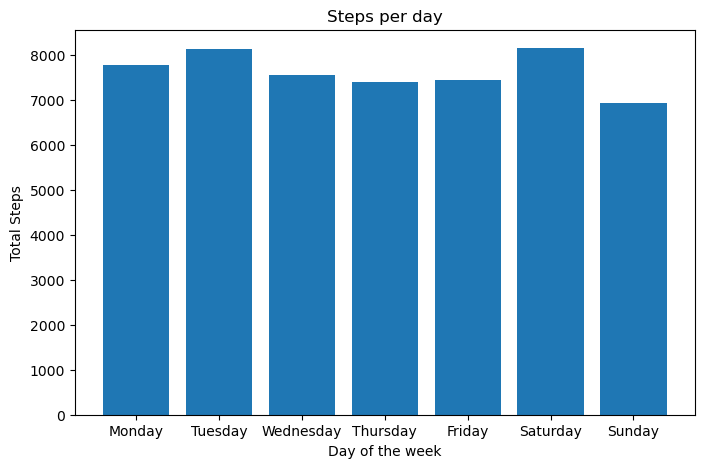

In [53]:
plt.figure(figsize=(8, 5))
plt.bar(avg_totalsteps.index, avg_totalsteps.values)
plt.title('Steps per day')
plt.xlabel('Day of the week')
plt.ylabel('Total Steps')
plt.show()

The day with the lowest average number of daily steps was Sunday, while the remaining days did not show major differences between one another. This may suggest that many users tend to rest on Sundays, engage in less physical activity, or spend more time at home compared to the rest of the week, resulting in a lower average step count for that day.

We continue by analyzing the average number of hours slept per day in order to identify possible patterns and variations in sleep behavior throughout the week.

In [54]:
avg_hoursasleep = sleep_day.groupby('WeekDay')['HoursAsleep'].mean()
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_hoursasleep = avg_hoursasleep.reindex(days)
avg_hoursasleep

WeekDay
Monday       6.991667
Tuesday      6.742308
Wednesday    7.244697
Thursday     6.688281
Friday       6.757018
Saturday     6.984503
Sunday       7.545758
Name: HoursAsleep, dtype: float64

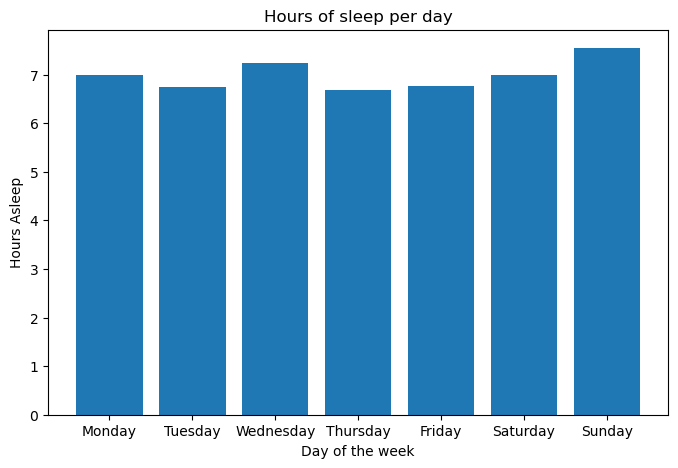

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(avg_hoursasleep.index, avg_hoursasleep.values)
plt.title('Hours of sleep per day')
plt.xlabel('Day of the week')
plt.ylabel('Hours Asleep')
plt.show()

By analyzing the graph, several important observations can be identified:
- Sunday is the day on which users tend to sleep the most on average compared to the rest of the week.
- This result appears to be consistent with the previous analysis, where Sunday also showed the lowest average number of daily steps.
- The combination of lower physical activity and higher sleep duration suggests that many users treat Sunday as a rest or recovery day.
- This behavior may also be influenced by fewer work or school responsibilities, allowing users to spend more time at home and maintain more relaxed routines.

After performing the correlation analysis between VeryActiveMinutes and Calories, the results showed a correlation value of 0.61, indicating a strong positive correlation between both variables.

In [66]:
daily_activity['VeryActiveMinutes'].corr(daily_activity['Calories'])

np.float64(0.6158382682703366)

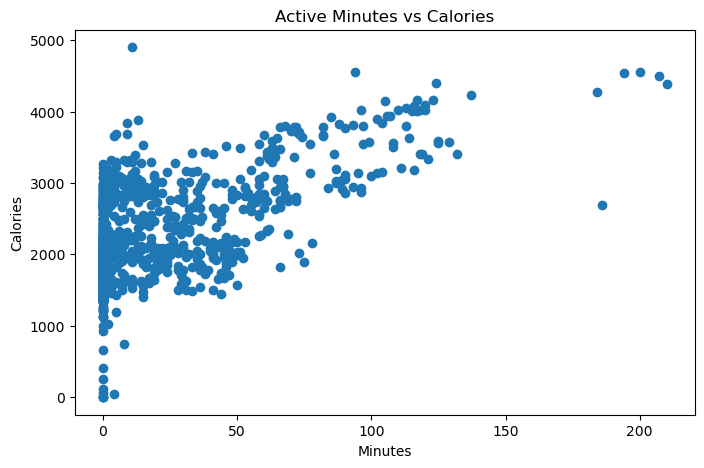

In [71]:
plt.figure(figsize=(8, 5))
plt.scatter(daily_activity['VeryActiveMinutes'], daily_activity['Calories'])
plt.title('Active Minutes vs Calories')
plt.xlabel('Minutes')
plt.ylabel('Calories')
plt.show()

- As the number of very active minutes increases, the number of calories burned also tends to increase.
- This strong positive relationship suggests that users who engage in higher levels of intense physical activity generally burn significantly more calories throughout the day.
- The correlation value reflects a clear connection between physical activity intensity and calorie expenditure, supporting the idea that more active users tend to have higher energy consumption.

In [45]:
merged_data['TotalSteps'].corr(merged_data['Calories'])

np.float64(0.40630067592096714)

Finally, we calculate the correlation between the total number of steps taken by users and the number of calories they burn. This analysis helps us understand the relationship between daily movement and calorie expenditure, allowing us to determine whether higher step counts are associated with greater amounts of calories burned.

In [46]:
daily_activity['TotalSteps'].corr(daily_activity['Calories'])

np.float64(0.5915680862453355)

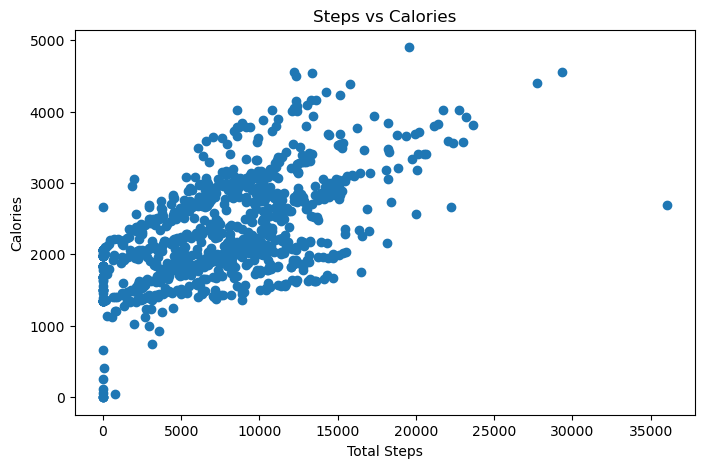

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(daily_activity['TotalSteps'], daily_activity['Calories'])
plt.title('Steps vs Calories')
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.show()

The correlation analysis between TotalSteps and Calories produced a value of 0.59, indicating a moderate positive correlation between both variables.
- This result suggests that as the number of steps taken increases, the number of calories burned also tends to increase.
- The relationship is relatively logical, since physical activity plays an important role in calorie expenditure and energy consumption.
- Although the correlation is not extremely strong, it still reflects a meaningful connection between daily movement and the amount of calories burned by users.

## Share
Tableu Dashboard:
https://public.tableau.com/views/BellabeatStudyCaseUserActivity/Dashboard1?:language=es-ES&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## Act
The analysis revealed that a considerable portion of users maintain sedentary lifestyles, reflected in low levels of daily activity and movement monitoring. This behavior may be influenced by several factors, such as static work environments, long office hours, the lack of additional physical activity outside of daily responsibilities, or simply maintaining lifestyles that are not very physically active.

In addition, Sundays showed the lowest average number of daily steps and the highest average sleep duration, suggesting that many users tend to use this day for rest and recovery. Furthermore, the correlation analyses demonstrated positive relationships between physical activity, step count, and calories burned, reinforcing the importance of movement and exercise in maintaining healthier habits and overall wellness.

Based on these findings, several recommendations can be proposed:

- Implement personalized smart notifications and reminders that encourage users to remain active throughout the day, especially during long periods of inactivity or sedentary behavior. These notifications could also remind users about recommended sleep schedules and healthier sleeping habits.
- Develop daily and weekly goals related to steps, calories burned, or physical activity time, helping users stay motivated and maintain healthier lifestyles. Additionally, activity challenges, rewards, or gamification systems could further increase engagement and encourage users to consistently achieve their goals.
- Promote features related to sleep tracking and recovery, allowing users to better understand the relationship between rest, physical activity, and overall wellness.
- Generate daily and weekly summaries showing relevant information such as total steps, calories burned, sleep hours, and activity levels. This would help users monitor their progress, identify areas for improvement, and remain consistently motivated.
- Encourage healthier weekend routines, particularly on Sundays, when users appear to be less physically active. This could include guided workouts, fitness recommendations, or motivational notifications designed to reduce sedentary behavior.
- Highlight metrics such as activity intensity, calories burned, sleep monitoring, and step tracking as key features in future marketing strategies, since the analysis demonstrated meaningful relationships between these variables and user wellness.

THANK YOU.